In [ ]:
# ==========================================
# CELL 1: IMPORT LIBRARIES
# ==========================================

# pandas is used for creating and manipulating
# tables/dataframes.
import pandas as pd

# numpy is used for numerical calculations
# and working with arrays.
import numpy as np

# matplotlib is used for creating graphs
# and visualizations.
import matplotlib.pyplot as plt

# seaborn is built on matplotlib and is useful
# for statistical visualizations.
import seaborn as sns

# load_breast_cancer() provides the
# Breast Cancer Wisconsin dataset.
from sklearn.datasets import load_breast_cancer

# These libraries will be used later for
# splitting, preprocessing, training and evaluation.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Evaluation metrics used to measure
# the performance of our model.
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ==========================================
# CELL 2: LOAD THE DATASET
# ==========================================

data = load_breast_cancer()

# Display the dataset object to understand
# what information it contains.
print(data)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [ ]:
# ==========================================
# CELL 3: DISPLAY FEATURE NAMES
# ==========================================

# data.feature_names contains the names
# of all input features.
print("Feature Names:")
print(data.feature_names)

# data.target_names contains the names
# of the two target classes.
print("\nTarget/Class Names:")
print(data.target_names)

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target/Class Names:
['malignant' 'benign']


In [ ]:
# ==========================================
# CELL 4: CREATE DATAFRAME
# ==========================================

# data.data contains the actual feature values.
# data.feature_names provides the column names.
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# Add the target/output column to the dataframe.
# data.target contains binary values:
# 0 and 1.
df['Outcome'] = data.target

# Display the first 5 rows.
# head() is used to see the beginning
# of a dataframe.
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# ==========================================
# CELL 5: CHECK DATASET SIZE
# ==========================================

# df.shape returns:
# (number of rows, number of columns)
print("Dataset Shape:", df.shape)

# Number of rows represents the number
# of patient/tumor observations.
print("Number of Rows:", df.shape[0])

# Number of columns represents the number
# of features plus the target column.
print("Number of Columns:", df.shape[1])

Dataset Shape: (569, 31)
Number of Rows: 569
Number of Columns: 31


In [ ]:
# ==========================================
# CELL 6: VIEW FIRST 5 ROWS
# ==========================================

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# ==========================================
# CELL 7: DATASET INFORMATION
# =========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
# ==========================================
# CELL 8: SUMMARY STATISTICS
# ==========================================

# describe() calculates important
# statistical information such as:
#
# count  -> number of observations
# mean   -> average value
# std    -> standard deviation

df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [ ]:
# ==========================================
# CELL 9: CALCULATE MEAN
# ==========================================

mean_values = df.mean(numeric_only=True)

print("Mean of each feature:")
print(mean_values)

Mean of each feature:
mean radius                 14.127292
mean texture                19.289649
mean perimeter              91.969033
mean area                  654.889104
mean smoothness              0.096360
mean compactness             0.104341
mean concavity               0.088799
mean concave points          0.048919
mean symmetry                0.181162
mean fractal dimension       0.062798
radius error                 0.405172
texture error                1.216853
perimeter error              2.866059
area error                  40.337079
smoothness error             0.007041
compactness error            0.025478
concavity error              0.031894
concave points error         0.011796
symmetry error               0.020542
fractal dimension error      0.003795
worst radius                16.269190
worst texture               25.677223
worst perimeter            107.261213
worst area                 880.583128
worst smoothness             0.132369
worst compactness           

In [ ]:
# ==========================================
# CELL 10: CALCULATE MEDIAN
# ==========================================

# median() finds the middle value
# of each numerical column.
#
# It is useful because median is less
# affected by extreme values/outliers.

median_values = df.median(numeric_only=True)

print("Median of each feature:")
print(median_values)

Median of each feature:
mean radius                 13.370000
mean texture                18.840000
mean perimeter              86.240000
mean area                  551.100000
mean smoothness              0.095870
mean compactness             0.092630
mean concavity               0.061540
mean concave points          0.033500
mean symmetry                0.179200
mean fractal dimension       0.061540
radius error                 0.324200
texture error                1.108000
perimeter error              2.287000
area error                  24.530000
smoothness error             0.006380
compactness error            0.020450
concavity error              0.025890
concave points error         0.010930
symmetry error               0.018730
fractal dimension error      0.003187
worst radius                14.970000
worst texture               25.410000
worst perimeter             97.660000
worst area                 686.500000
worst smoothness             0.131300
worst compactness         

In [ ]:
# ==========================================
# CELL 11: STANDARD DEVIATION
# ==========================================

# std() calculates standard deviation.

std_values = df.std(numeric_only=True)

print("Standard Deviation:")
print(std_values)

Standard Deviation:
mean radius                  3.524049
mean texture                 4.301036
mean perimeter              24.298981
mean area                  351.914129
mean smoothness              0.014064
mean compactness             0.052813
mean concavity               0.079720
mean concave points          0.038803
mean symmetry                0.027414
mean fractal dimension       0.007060
radius error                 0.277313
texture error                0.551648
perimeter error              2.021855
area error                  45.491006
smoothness error             0.003003
compactness error            0.017908
concavity error              0.030186
concave points error         0.006170
symmetry error               0.008266
fractal dimension error      0.002646
worst radius                 4.833242
worst texture                6.146258
worst perimeter             33.602542
worst area                 569.356993
worst smoothness             0.022832
worst compactness            0

In [ ]:
# ==========================================
# CELL 12: COMBINED SUMMARY
# ==========================================

# Create a new dataframe containing
# three important statistics for every feature.

summary = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Standard Deviation': df.std(numeric_only=True)
})

# Display the summary table.
summary

,Mean,Median,Standard Deviation
mean radius,14.127292,13.370000,3.524049
mean texture,19.289649,18.840000,4.301036
mean perimeter,91.969033,86.240000,24.298981
mean area,654.889104,551.100000,351.914129
mean smoothness,0.096360,0.095870,0.014064
mean compactness,0.104341,0.092630,0.052813
mean concavity,0.088799,0.061540,0.079720
mean concave points,0.048919,0.033500,0.038803
mean symmetry,0.181162,0.179200,0.027414
mean fractal dimension,0.062798,0.061540,0.007060


In [ ]:
# ==========================================
# CELL 13: CHECK MISSING VALUES
# ==========================================

# isnull() checks every cell and returns:
# True  -> value is missing
# False -> value is present
#
# sum() counts the number of missing
# values in each column.

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Outcome                    0
dtype: int64


In [ ]:
# ==========================================
# TOTAL NUMBER OF MISSING VALUES
# ==========================================

# The first sum() calculates missing values
# for each column.
#
# The second sum() calculates the total
# missing values across the entire dataset.

total_missing = df.isnull().sum().sum()

print("Total Missing Values:", total_missing)

Total Missing Values: 0


In [ ]:
# ==========================================
# CELL 14: CHECK DUPLICATES
# ==========================================

# duplicated() checks whether a row
# is an exact duplicate of a previous row.
#
# sum() counts how many duplicate rows exist.

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# ==========================================
# REMOVE DUPLICATES IF REQUIRED
# ==========================================

# drop_duplicates() removes duplicate rows.
#
# This line should only be used if
# duplicate_count is greater than 0.

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (569, 31)


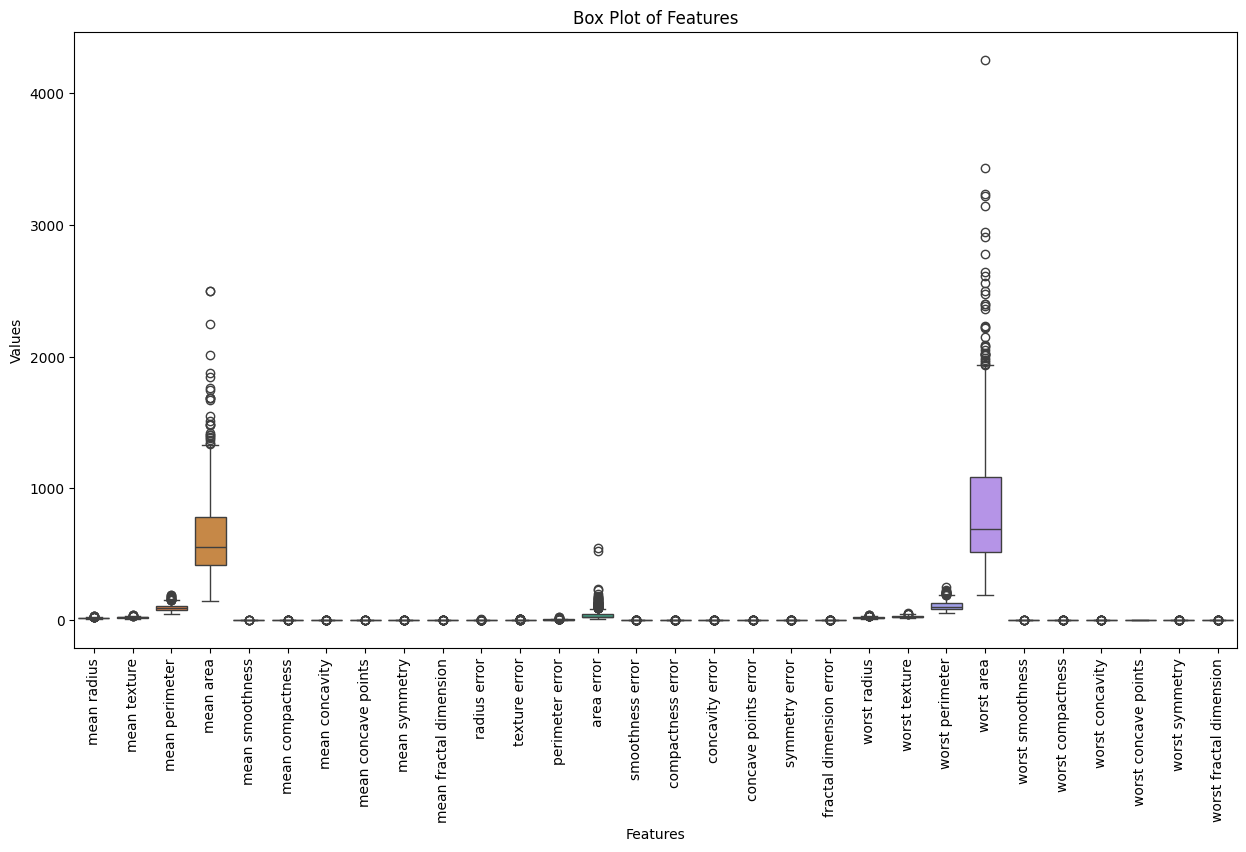

In [ ]:
# ==========================================
# CELL 15: OUTLIER DETECTION
# ==========================================

# Create a large figure so all feature
# box plots can be displayed clearly.
plt.figure(figsize=(15, 8))

# Remove the Outcome column because
# it is our target, not a feature.
#
# boxplot() displays the distribution
# and possible outliers of each feature.
sns.boxplot(data=df.drop(columns=['Outcome']))

# Rotate feature names so they
# don't overlap.
plt.xticks(rotation=90)

plt.title("Box Plot of Features")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

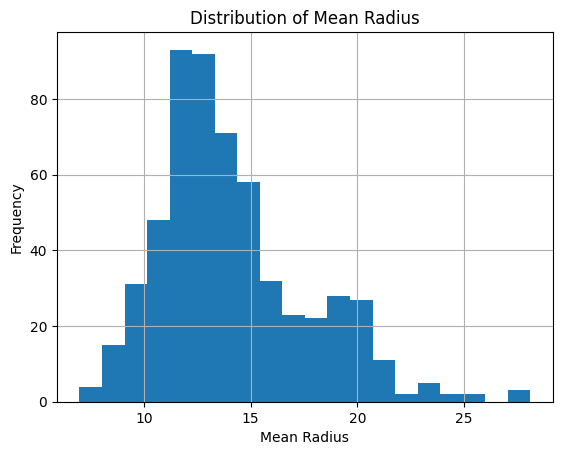

In [ ]:
# ==========================================
# CELL 16: HISTOGRAM
# ==========================================

# Select the "mean radius" feature.
#
# hist() creates a histogram showing
# how frequently different values occur.
df['mean radius'].hist(bins=20)

plt.title("Distribution of Mean Radius")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")

plt.show()

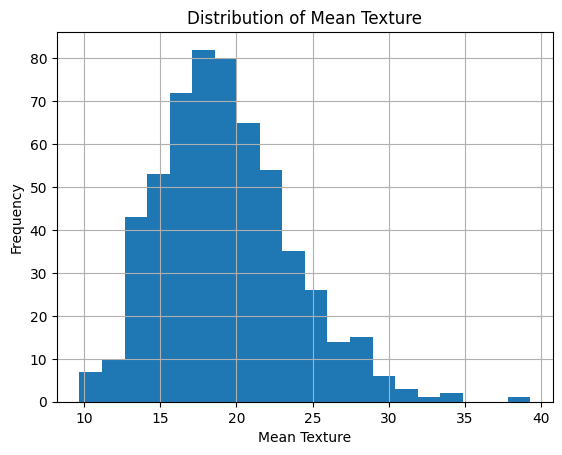

In [ ]:
# ==========================================
# CELL 17: HISTOGRAM OF MEAN TEXTURE
# ==========================================

# Create a histogram for another
# important feature: mean texture.

df['mean texture'].hist(bins=20)

plt.title("Distribution of Mean Texture")
plt.xlabel("Mean Texture")
plt.ylabel("Frequency")

plt.show()

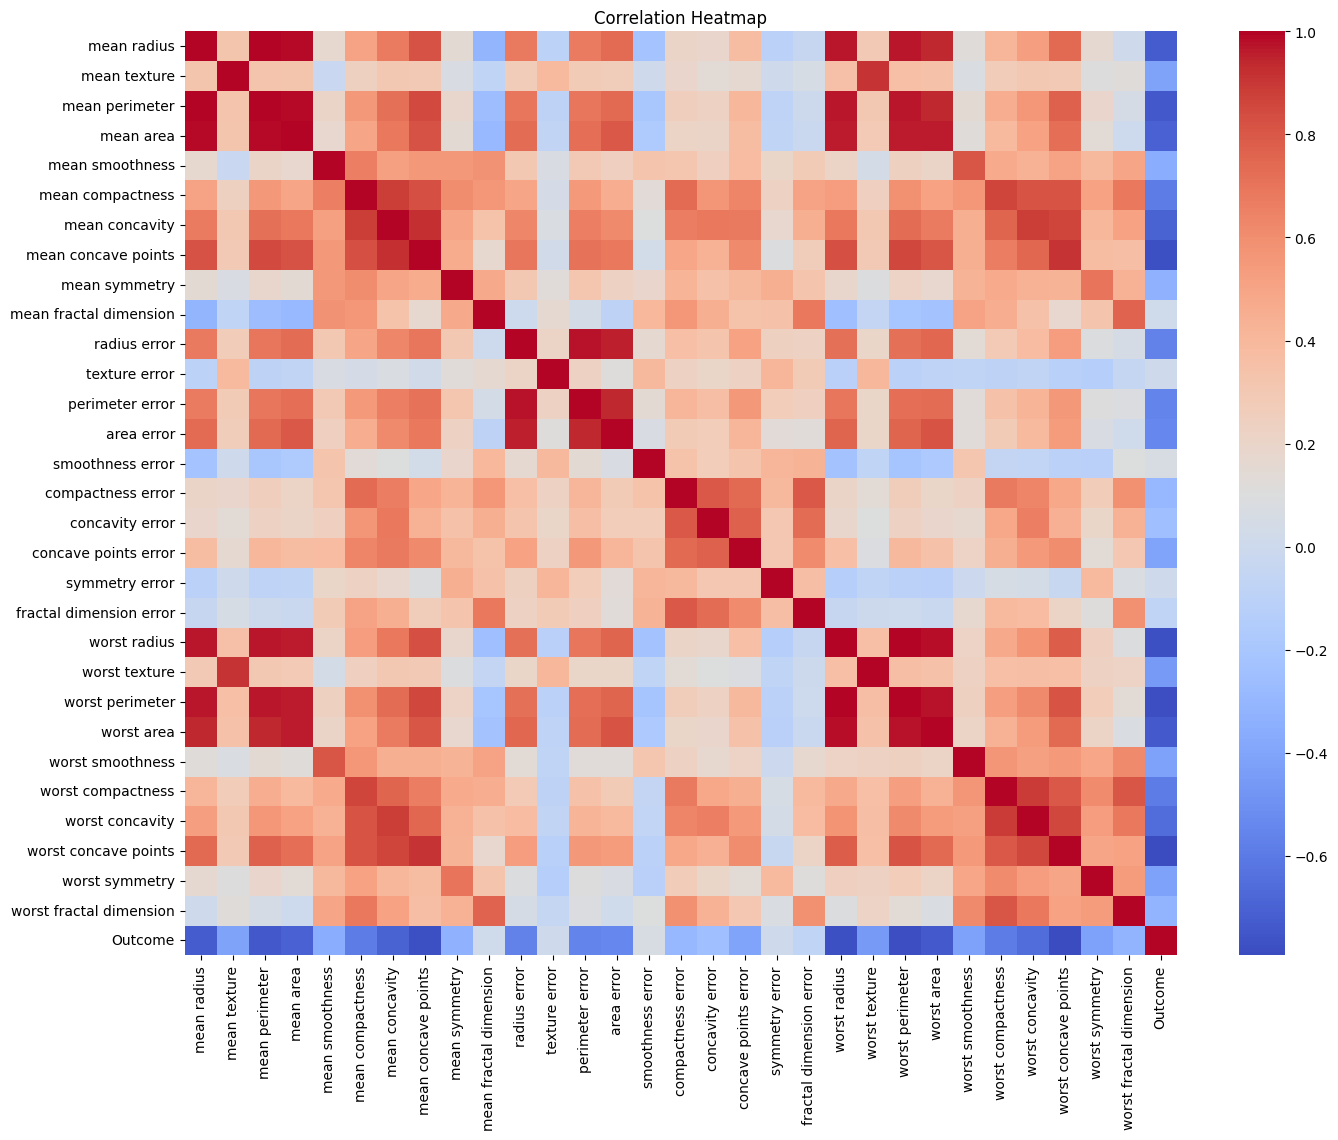

In [ ]:
# ==========================================
# CELL 18: CORRELATION HEATMAP
# ==========================================

# corr() calculates the correlation
# between every pair of numerical columns.
correlation = df.corr()

# Create a large figure for readability.
plt.figure(figsize=(16, 12))

# heatmap() represents correlation values
# using different shades.
#
# annot=False is used because there are
# many features and displaying every number
# would make the graph difficult to read.
sns.heatmap(
    correlation,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# ==========================================
# CELL 19: CLASS DISTRIBUTION
# ==========================================

# value_counts() counts how many
# observations belong to each class.

class_counts = df['Outcome'].value_counts()

print("Class Distribution:")
print(class_counts)

Class Distribution:
Outcome
1    357
0    212
Name: count, dtype: int64


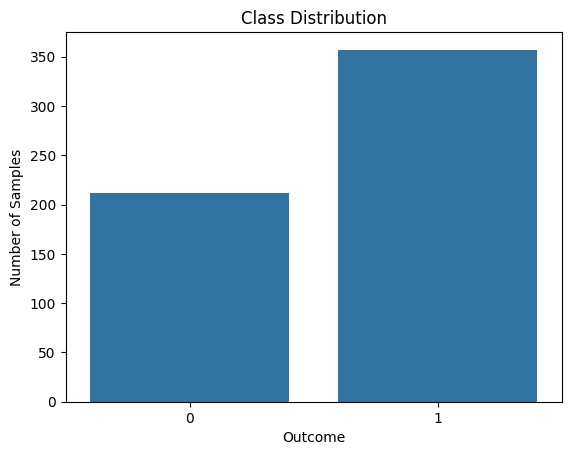

In [ ]:
# ==========================================
# CELL 20: CLASS DISTRIBUTION GRAPH
# ==========================================

# countplot() creates a bar graph showing
# the number of observations in each class.

sns.countplot(x='Outcome', data=df)

plt.title("Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
# ==========================================
# CELL 21: SEPARATE X AND y
# ==========================================

# X contains all input features.
#
# We remove 'Outcome' because Outcome
# is what we want the model to predict.

X = df.drop('Outcome', axis=1)

# y contains the target/output variable.
y = df['Outcome']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (569, 30)
Target (y) shape: (569,)


In [ ]:
# ==========================================
# CELL 22: CHECK TARGET ENCODING
# ==========================================

# unique() returns all different values
# present in the target column.

print("Unique target values:")
print(y.unique())

# value_counts() tells us how many
# observations belong to each class.
print("\nTarget distribution:")
print(y.value_counts())

Unique target values:
[0 1]

Target distribution:
Outcome
1    357
0    212
Name: count, dtype: int64


In [ ]:
# ==========================================
# CELL 23: TRAIN-TEST SPLIT
# ==========================================

# train_test_split() divides our data into:
#
# 80% -> Training data
# 20% -> Testing data
#
# random_state=42 ensures that we get
# the same split every time we run the code.
#
# stratify=y maintains approximately
# the same class distribution in both
# training and testing datasets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [ ]:
# ==========================================
# CELL 24: STANDARDIZE FEATURES
# ==========================================

# StandardScaler converts features
# to approximately:
#
# Mean = 0
# Standard deviation = 1
#
# This makes features with different
# numerical scales comparable.

scaler = StandardScaler()

# fit_transform():
# 1. fit() learns the mean and standard
#    deviation from the TRAINING data.
# 2. transform() uses those values
#    to standardize the training data.

X_train_scaled = scaler.fit_transform(X_train)

# IMPORTANT:
# For test data we only use transform().
#
# We do NOT fit the scaler again because
# that would allow information from the
# test data to influence preprocessing.

X_test_scaled = scaler.transform(X_test)

print("Training data standardized.")
print("Testing data standardized.")

Training data standardized.
Testing data standardized.


In [ ]:
# ==========================================
# CELL 25: CREATE MODEL
# ==========================================

# LogisticRegression() creates a machine
# learning model used for classification.
#
# Since our target has two classes,
# Logistic Regression is suitable for
# this binary classification problem.
#
# max_iter=1000 allows the algorithm
# enough iterations to find a solution.

model = LogisticRegression(max_iter=1000)

print("Logistic Regression model created.")

Logistic Regression model created.


In [ ]:
# ==========================================
# CELL 26: TRAIN THE MODEL
# ==========================================

# fit() trains the machine learning model.
#
# X_train_scaled -> training features
# y_train        -> correct class labels
#
# During training, Logistic Regression
# learns the relationship between the
# medical features and the target class.

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
# ==========================================
# CELL 27: MAKE PREDICTIONS
# ==========================================

# predict() uses the trained model
# to predict the class of unseen
# test observations.

y_pred = model.predict(X_test_scaled)

# Display the first 20 predictions.
print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


In [ ]:
# ==========================================
# CELL 28: ACTUAL VS PREDICTED
# ==========================================

# Create a small dataframe to compare
# actual labels with model predictions.

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

# Display first 20 results.
comparison.head(20)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,1,1
6,1,1
7,0,0
8,0,0
9,0,0


In [ ]:
# ==========================================
# CELL 29: ACCURACY
# ==========================================

# accuracy_score() calculates:
#
# Correct predictions / Total predictions
#
# It returns a value between 0 and 1.

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Convert accuracy into percentage.
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9824561403508771
Accuracy Percentage: 98.24561403508771 %


In [ ]:
# ==========================================
# CELL 30: CLASSIFICATION REPORT
# ==========================================

# classification_report() calculates:
#
# Precision
# Recall
# F1-score
# Support
#
# for each class separately.

report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
# ==========================================
# CELL 31: CONFUSION MATRIX
# ==========================================

# confusion_matrix() compares:
#
# Actual class
#        VS
# Predicted class
#
# It returns a matrix showing
# correct and incorrect predictions.

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 1 71]]


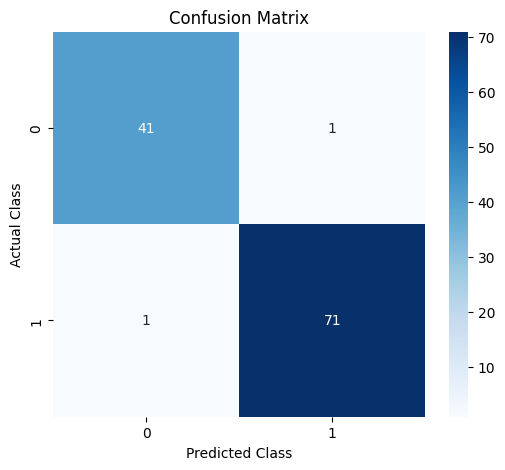

In [ ]:
# ==========================================
# CELL 32: CONFUSION MATRIX VISUALIZATION
# ==========================================

# Create a figure.
plt.figure(figsize=(6, 5))

# heatmap() displays the confusion matrix
# in an easy-to-understand graphical form.
#
# annot=True displays the actual numbers.
# fmt='d' displays numbers as integers.

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# ==========================================
# CELL 33: ROC AND AUC
# ==========================================

# predict_proba() returns the probability
# of each sample belonging to each class.
#
# [:, 1] selects the probability of class 1.

y_prob = model.predict_proba(X_test_scaled)[:, 1]

# roc_curve() calculates:
#
# FPR = False Positive Rate
# TPR = True Positive Rate
#
# at different classification thresholds.

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

# roc_auc_score() calculates the
# Area Under the ROC Curve.
#
# Higher AUC generally means better
# ability to distinguish between classes.

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("AUC Score:", auc_score)

AUC Score: 0.9953703703703703


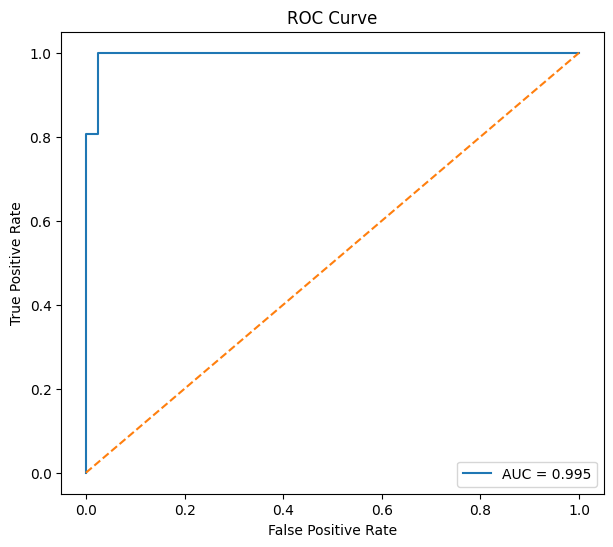

In [ ]:
# ==========================================
# CELL 34: ROC CURVE
# ==========================================

# Create a figure.
plt.figure(figsize=(7, 6))

# Plot the ROC curve.
#
# x-axis = False Positive Rate
# y-axis = True Positive Rate
#
# The label displays the AUC value.

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc_score:.3f}'
)

# This diagonal line represents
# approximately random classification.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

# Display the AUC value on the graph.
plt.legend()

plt.show()

In [ ]:
# ==========================================
# CELL 35: FINAL MODEL RESULTS
# ==========================================

print("======================================")
print("      LOGISTIC REGRESSION RESULTS")
print("======================================")

# Display accuracy.
print(f"Accuracy : {accuracy:.4f}")

# Display AUC.
print(f"AUC Score: {auc_score:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("======================================")

      LOGISTIC REGRESSION RESULTS
Accuracy : 0.9825
AUC Score: 0.9954

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

